In [1]:
FILTER_ZEROS = False
THRESHOLD = 1

In [2]:
import pandas as pd
import glob
import numpy as np

files = glob.glob("./unconstrained_results/*.parquet")

df_all = pd.concat(
    [pd.read_parquet(f) for f in files],
    ignore_index=True
)

print(df_all.shape)
df_all.head()

(328770, 30)


,Date,Origin,Destination,Scheduled_Flights,Final_True_Demand,Final_Constrained_Bookings,Is_Censored,Final_Price_per_kg,Elasticity_Factor,BOH_DP15,...,BOH_DP4,BOH_DP3,BOH_DP2,BOH_DP1,Fuzzy_Capacity,Naive_Est,EM_Est,MARSS_Est,EMXPrice_Est,MARSSXPrice_Est
0,2016-01-01,CAN,CGO,1,17244.0,17244.0,False,2.709220,0.975512,2579.0,...,15523.0,16269.0,16867.0,17244.0,100000.0,NaN,NaN,NaN,NaN,NaN
1,2016-01-02,CAN,CGO,1,12891.0,12891.0,False,2.205106,1.104346,1928.0,...,11605.0,12162.0,12609.0,12891.0,100000.0,NaN,NaN,NaN,NaN,NaN
2,2016-01-03,CAN,CGO,1,9708.0,9708.0,False,1.820000,1.239734,1452.0,...,8739.0,9159.0,9496.0,9708.0,100000.0,NaN,NaN,NaN,NaN,NaN
3,2016-01-04,CAN,CGO,1,14251.0,14251.0,False,2.670507,0.984008,2131.0,...,12828.0,13445.0,13939.0,14251.0,100000.0,NaN,NaN,NaN,NaN,NaN
4,2016-01-05,CAN,CGO,1,18868.0,18868.0,False,1.981157,1.177953,2822.0,...,16985.0,17801.0,18455.0,18868.0,100000.0,NaN,NaN,NaN,NaN,NaN


In [3]:
# 1. Define your estimation columns
est_columns = ['Naive_Est', 'EM_Est', 'MARSS_Est', 'EMXPrice_Est', 'MARSSXPrice_Est']

# 2. Function to trim the burn-in period for a single OD pair
def trim_burn_in(df_group):
    # Find the first row where ALL estimation columns have valid (non-NaN) data
    # If some models burn-in faster than others, this ensures we wait for the slowest one
    valid_mask = df_group[est_columns].notna().all(axis=1)
    
    if not valid_mask.any():
        return pd.DataFrame() # Return empty if the models never converged
        
    first_valid_idx = valid_mask.idxmax() 
    
    # Return the dataframe from the first valid index to the end
    return df_group.loc[first_valid_idx:].copy()

# 3. Apply the trimming per OD pair
df_trimmed = df_all.groupby(['Origin', 'Destination'], as_index=False, group_keys=False).apply(trim_burn_in)

# 4. (Optional but recommended) Fill any remaining NaNs AFTER the burn-in
# If your models output NaN on later days simply because the day was uncensored, 
# you still need to fill those with the observed bookings so the forecaster doesn't crash.
for col in est_columns:
    df_trimmed[col] = df_trimmed[col].fillna(df_trimmed['Final_Constrained_Bookings'])

print(f"Original shape: {df_all.shape}")
print(f"Trimmed shape: {df_trimmed.shape}")

df_all = df_trimmed.reset_index(drop=True)

Original shape: (328770, 30)
Trimmed shape: (295920, 30)


In [4]:
models = ["Naive_Est", "EM_Est", "MARSS_Est", "EMXPrice_Est", "MARSSXPrice_Est"]

results = []

# Evaluate route-by-route first
for col in models:

    route_metrics = []

    for (o, d), g in df_all.groupby(["Origin", "Destination"]):

        y_true = g["Final_True_Demand"]
        y_pred = g[col]

        mask = y_pred.notna()

        if mask.sum() == 0:
            continue

        yt = y_true[mask].values
        yp = y_pred[mask].values

        mse = np.mean((yt - yp) ** 2)
        mae = np.mean(np.abs(yt - yp))
        rmse = np.sqrt(mse)

        # Optional filter:
        # remove OD pairs that are essentially zero-error / trivial
        if FILTER_ZEROS and (mae + mse + rmse < THRESHOLD):
            print(f"Skipping OD pair ({o} -> {d}) due to low error: MAE={mae:.4f}, MSE={mse:.4f}, RMSE={rmse:.4f}")
            continue

        route_metrics.append((mae, mse, rmse))

    # Aggregate remaining OD pairs
    if len(route_metrics) == 0:
        avg_mae = np.nan
        avg_mse = np.nan
        avg_rmse = np.nan
        n_routes = 0
    else:
        arr = np.array(route_metrics)
        avg_mae = arr[:, 0].mean()
        avg_mse = arr[:, 1].mean()
        avg_rmse = arr[:, 2].mean()
        n_routes = len(route_metrics)

    results.append({
        "Model": col,
        "Routes_Used": n_routes,
        "MAE": avg_mae,
        "MSE": avg_mse,
        "RMSE": avg_rmse
    })

metrics_df = pd.DataFrame(results)
metrics_df

,Model,Routes_Used,MAE,MSE,RMSE
0,Naive_Est,90,413.835452,9.058741e+06,2196.685997
1,EM_Est,90,268.315056,4.074551e+06,1482.318450
2,MARSS_Est,90,266.867503,3.557238e+06,1398.314039
3,EMXPrice_Est,90,262.718275,3.882913e+06,1448.438447
4,MARSSXPrice_Est,90,257.800473,3.350543e+06,1358.646469


In [5]:
pair_results = []

for (o, d), g in df_all.groupby(["Origin", "Destination"]):

    y_true = g["Final_True_Demand"]

    row = {
        "Origin": o,
        "Destination": d
    }

    for col in models:

        mask = g[col].notna()

        mse = np.mean((y_true[mask] - g[col][mask])**2)
        mae = np.mean(np.abs(y_true[mask] - g[col][mask]))

        row[f"{col}_MAE"] = mae
        row[f"{col}_MSE"] = mse

    pair_results.append(row)

pair_df = pd.DataFrame(pair_results)
pair_df.to_csv("pairwise_metrics.csv", index=False)
pair_df.head()

,Origin,Destination,Naive_Est_MAE,Naive_Est_MSE,EM_Est_MAE,EM_Est_MSE,MARSS_Est_MAE,MARSS_Est_MSE,EMXPrice_Est_MAE,EMXPrice_Est_MSE,MARSSXPrice_Est_MAE,MARSSXPrice_Est_MSE
0,CAN,CGO,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00
1,CAN,HKG,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00
2,CAN,JFK,143.929136,2.516883e+06,91.100558,1.317955e+06,93.296260,1.192441e+06,90.417560,1.284091e+06,90.882355,1.152584e+06
3,CAN,LAX,400.303832,8.216463e+06,248.463461,3.952077e+06,237.394242,3.523015e+06,246.828287,3.814280e+06,233.489269,3.381931e+06
4,CAN,NRT,726.755779,1.370328e+07,470.774255,5.827347e+06,486.378423,5.388262e+06,457.900415,5.510550e+06,461.630631,4.936190e+06


In [6]:
pair_df["Best_Model"] = pair_df[
    ["Naive_Est_MAE", "EM_Est_MAE", "MARSS_Est_MAE", "EMXPrice_Est_MAE", "MARSSXPrice_Est_MAE"]
].idxmin(axis=1)

pair_df[["Origin", "Destination", "Best_Model"]]

,Origin,Destination,Best_Model
0,CAN,CGO,Naive_Est_MAE
1,CAN,HKG,Naive_Est_MAE
2,CAN,JFK,EMXPrice_Est_MAE
3,CAN,LAX,MARSSXPrice_Est_MAE
4,CAN,NRT,EMXPrice_Est_MAE
...,...,...,...
85,SIN,LAX,EMXPrice_Est_MAE
86,SIN,NRT,EMXPrice_Est_MAE
87,SIN,ORD,EMXPrice_Est_MAE
88,SIN,PEK,MARSSXPrice_Est_MAE


In [8]:
# Create a mapping that checks if an OD pair was EVER censored
od_censored_status = df_all.groupby(['Origin', 'Destination'])['Is_Censored'].any().reset_index()
od_censored_status.rename(columns={'Is_Censored': 'Ever_Censored'}, inplace=True)

# Merge this status back to the main DataFrame
df_all = df_all.merge(od_censored_status, on=['Origin', 'Destination'])

# Split into Group A (Constrained) and Group B (Unconstrained)
group_a = df_all[df_all['Ever_Censored'] == True].copy()
group_b = df_all[df_all['Ever_Censored'] == False].copy()

# Optional: drop the helper column to keep things clean
group_a.drop(columns=['Ever_Censored'], inplace=True)
group_b.drop(columns=['Ever_Censored'], inplace=True)

print(f"Group A (Constrained) shape: {group_a.shape}")
print(f"Group B (Unconstrained) shape: {group_b.shape}")

Group A (Constrained) shape: (246600, 30)
Group B (Unconstrained) shape: (49320, 30)


C:\Users\Ming\AppData\Local\Temp\ipykernel_30144\3819989706.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='Group', y='Final_True_Demand', palette='Set2')


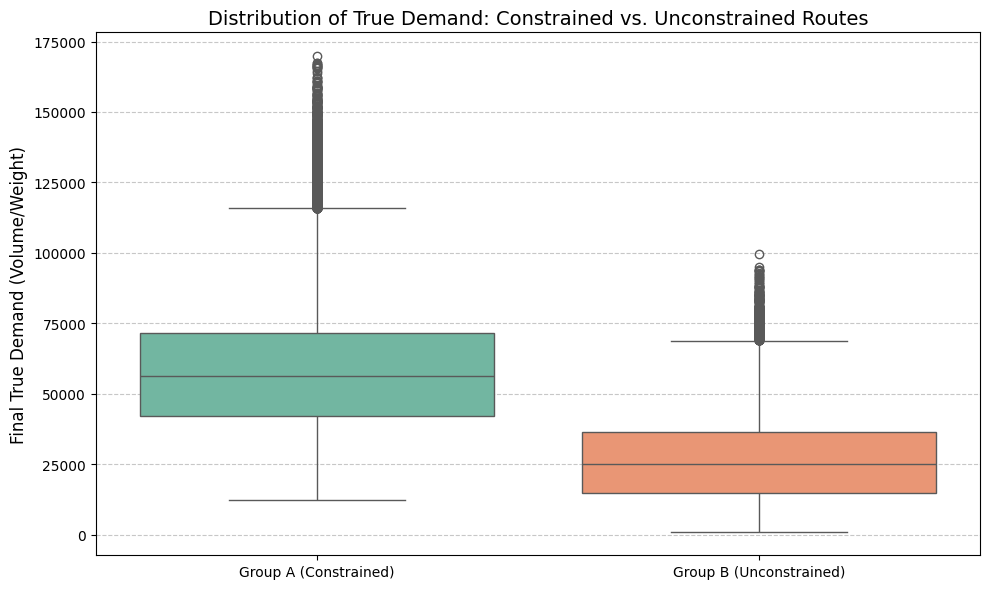

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a combined temporary DataFrame just for the plot
plot_data = pd.DataFrame({
    'Group': ['Group A (Constrained)'] * len(group_a) + ['Group B (Unconstrained)'] * len(group_b),
    'Final_True_Demand': pd.concat([group_a['Final_True_Demand'], group_b['Final_True_Demand']])
})

# Generate the boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=plot_data, x='Group', y='Final_True_Demand', palette='Set2')

# Add titles and labels
plt.title('Distribution of True Demand: Constrained vs. Unconstrained Routes', fontsize=14)
plt.ylabel('Final True Demand (Volume/Weight)', fontsize=12)
plt.xlabel('')

# Add a grid for easier reading
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()